# Western Balkan Regions (WB6)


## Set Required Args to Initialize Objects

- All steps are integrated in this 'RES_module.build()' method.

In [1]:
import RES.RESources as RES

# Iterate over provinces for both solar and wind resources
resource_types = ['wind']  # 'solar'
countries=['AL']  #,'BA','XK','ME','MK','RS'
for country_code in countries:
    for resource_type in resource_types:
        required_args = {
            "config_file_path": 'config/config_WB6.yaml',
            "region_short_code": country_code,
            "resource_type": resource_type
        }
        
        # Create an instance of Resources and execute the module
        RES_module = RES.RESources_builder(**required_args)
        
    
    # For complete workflow, uncomment the following line
        # RES_module.build(select_top_sites=True,
        #                  use_pypsa_buses=False)  

 └> CODERS API key loaded from: data/downloaded_data/CODERS/coders_api.yaml
  └> user Elias: w0OksqQKMFMtKPbO
____________________________________________________________
     Initiating RESource Builder | RES.RESources
____________________________________________________________
  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
Conservation Lands data supply chain is configured for Canada only
⚠️  RES.lands| 'conserved_lands_CAN' not initiated. Please check the config file for 'conserved_lands' key under 'Gov' section
 └> NREL_ATBProcessor initiated...
  └> RES.atb| Processing Annual Technology Baseline (ATB) data sourced from NREL...
 └> RES.utility| Directory 'data/downloaded_data/NREL/ATB/ATBe.parquet' found locally.
  └> RES.atb| ATB 

# Stepwise Checks/Debugging [when required]

### Step 1: Prepare Spatial Grid Cells

In [2]:
cells=RES_module.gridcells.get_default_grid()

  └─> RES.era5_cutout|  Processing ERA5's cutout...
  └─> RES.boundaries| Processing regional bounding box...
  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
  └─> RES.boundaries| Setting up the Minimum Bounding Region (MBR) for AL...
  └─> RES.era5_cutout| ✓ MBR and regional boundary created. 
ℹ️   Memory management remarks:
    * After execution, all downloaded data is stored at cutout.path. By default, it is not loaded into memory, but into dask arrays. This keeps the memory consumption extremely low.
    * The data is accessible in cutout.data, which is an xarray.Dataset. Querying the cutout gives us some basic information on which data is contained in it.
    * For more operations related to cutout, check the tool docs @ https://atl

In [3]:
step1_results=RES_module.get_grid_cells()

step1_results.head(5) # See the first 5 rows of the grid cells data

 └> RES.RESources| Preparing Grid Cells...
  └─> RES.era5_cutout|  Processing ERA5's cutout...
  └─> RES.boundaries| Processing regional bounding box...
  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
  └─> RES.boundaries| Setting up the Minimum Bounding Region (MBR) for AL...
  └─> RES.era5_cutout| ✓ MBR and regional boundary created. 
ℹ️   Memory management remarks:
    * After execution, all downloaded data is stored at cutout.path. By default, it is not loaded into memory, but into dask arrays. This keeps the memory consumption extremely low.
    * The data is accessible in cutout.data, which is an xarray.Dataset. Querying the cutout gives us some basic information on which data is contained in it.
    * For more operations related t

,x,y,Country,Municipality,City,geometry
cell,,,,,,
Delvinës_20.0_39.75,20.00,39.75,Albania,Vlorë,Delvinës,"POLYGON ((20.11477 39.875, 20.1115 39.8736, 20..."
Sarandës_20.0_39.75,20.00,39.75,Albania,Vlorë,Sarandës,"POLYGON ((20.125 39.875, 20.125 39.65789, 20.1..."
Gjirokastrës_20.25_39.75,20.25,39.75,Albania,Gjirokastër,Gjirokastrës,"POLYGON ((20.375 39.875, 20.375 39.7811, 20.36..."
Delvinës_20.25_39.75,20.25,39.75,Albania,Vlorë,Delvinës,"POLYGON ((20.23679 39.875, 20.2378 39.8698, 20..."
Sarandës_20.25_39.75,20.25,39.75,Albania,Vlorë,Sarandës,"POLYGON ((20.125 39.875, 20.18241 39.875, 20.1..."


### Step 2: Calculate Potential Capacity

 └> RES.RESources| Preparing Cells' capacity...
  └> RES.CellCapacityProcessor| Cell capacity processor initiated...
  └─> RES.era5_cutout|  Processing ERA5's cutout...
  └─> RES.boundaries| Processing regional bounding box...
  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
  └─> RES.boundaries| Setting up the Minimum Bounding Region (MBR) for AL...
  └─> RES.era5_cutout| ✓ MBR and regional boundary created. 
ℹ️   Memory management remarks:
    * After execution, all downloaded data is stored at cutout.path. By default, it is not loaded into memory, but into dask arrays. This keeps the memory consumption extremely low.
    * The data is accessible in cutout.data, which is an xarray.Dataset. Querying the cutout gives us some basic informa

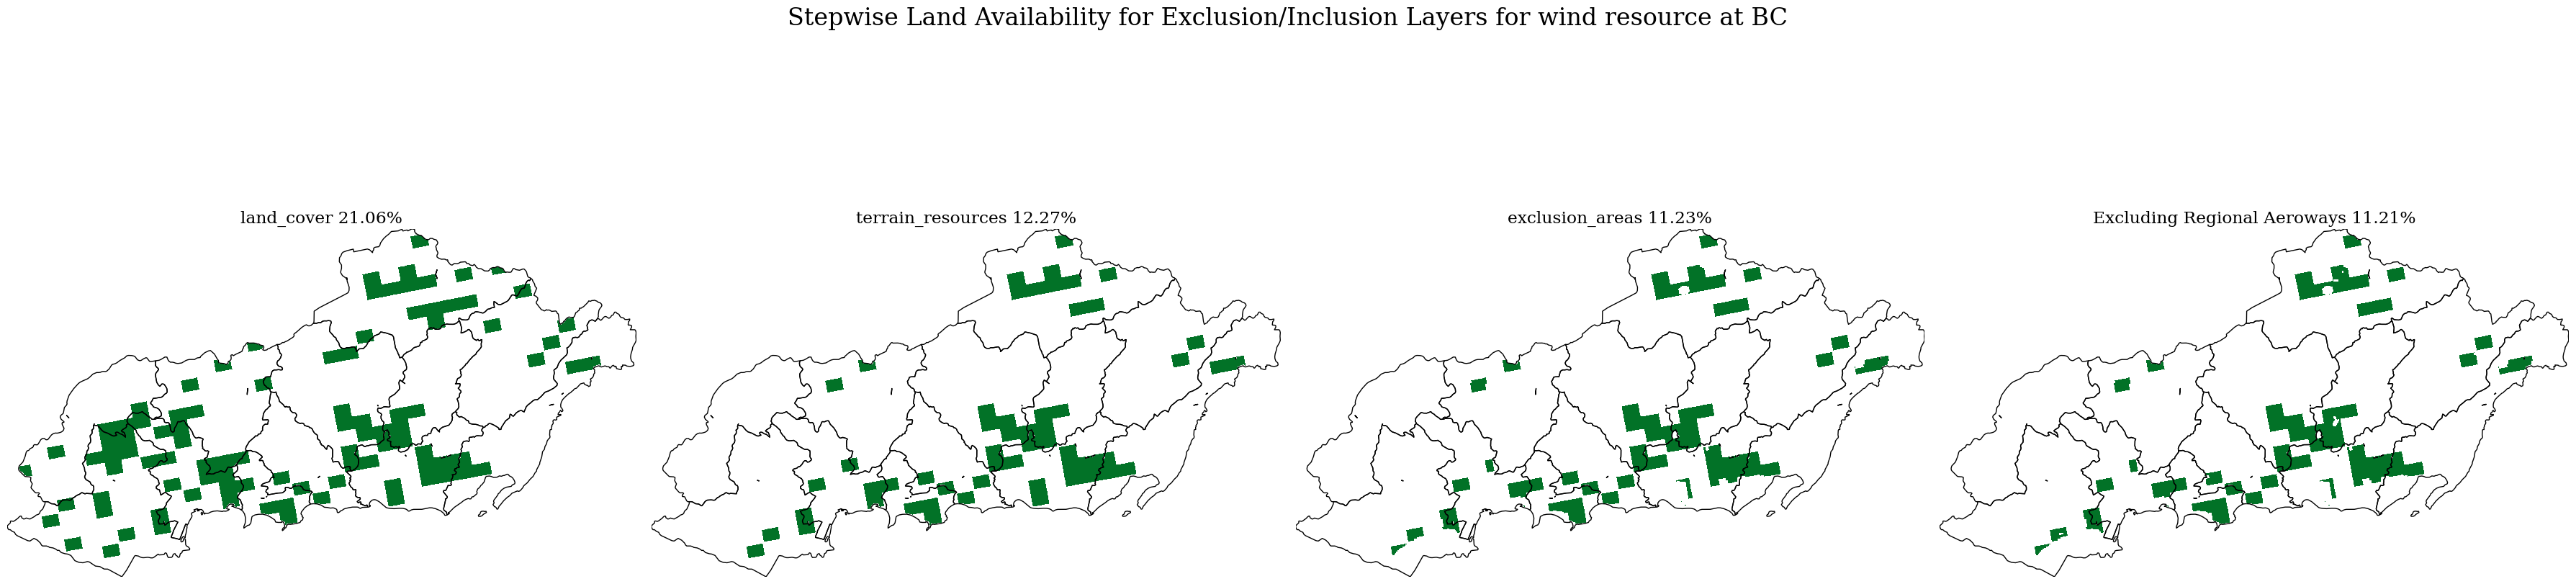

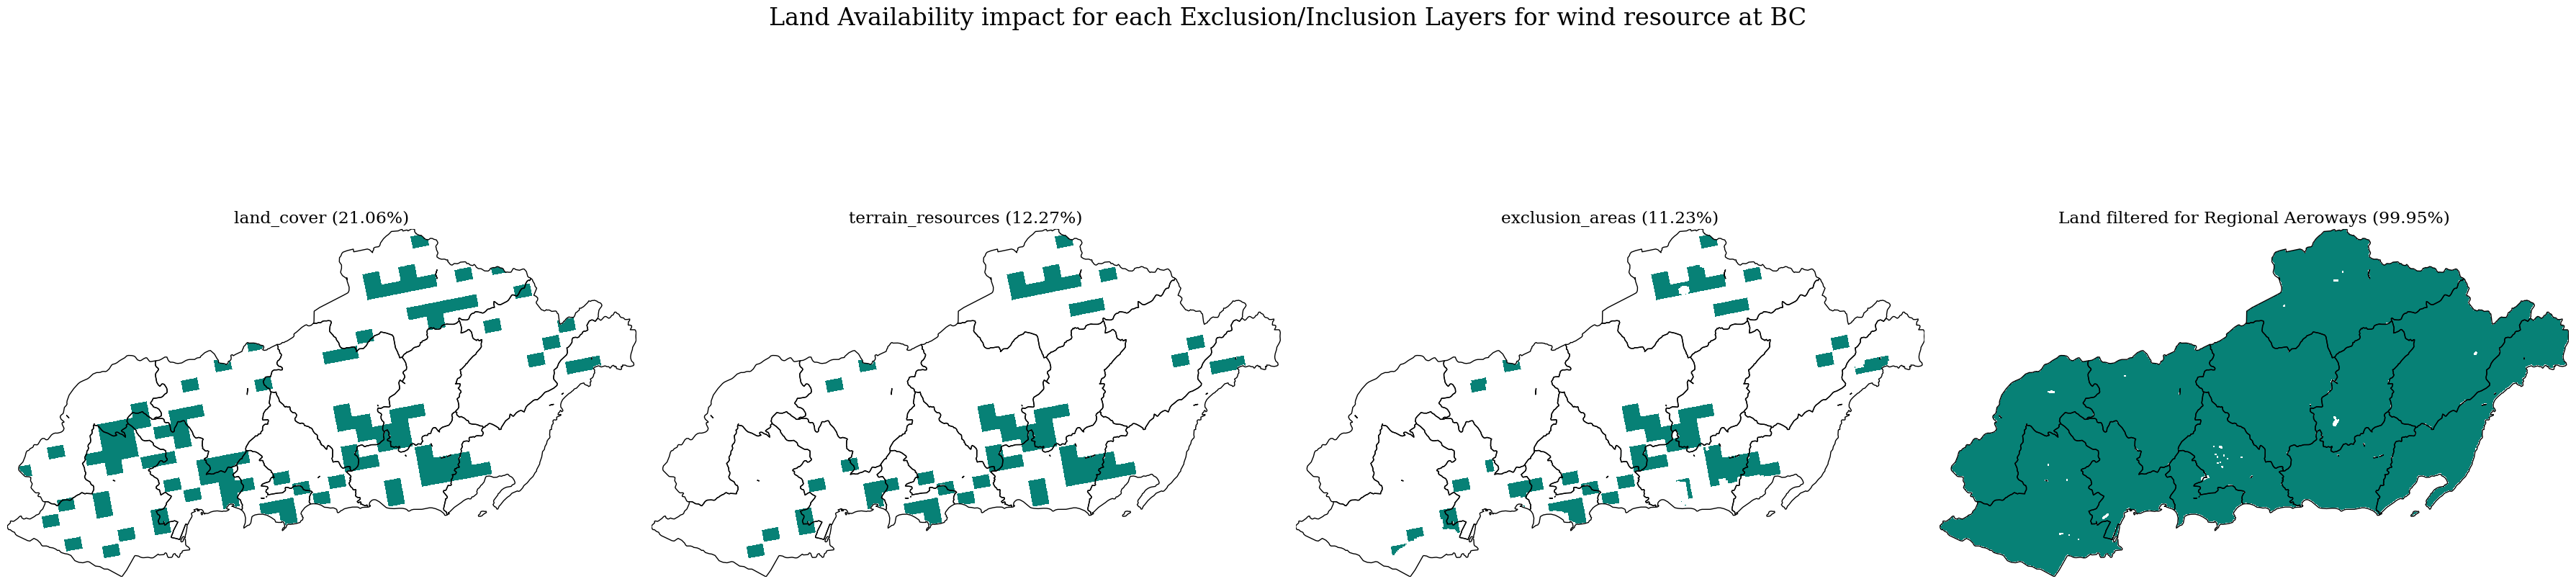

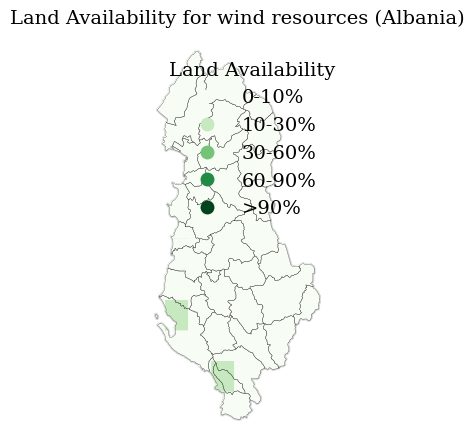

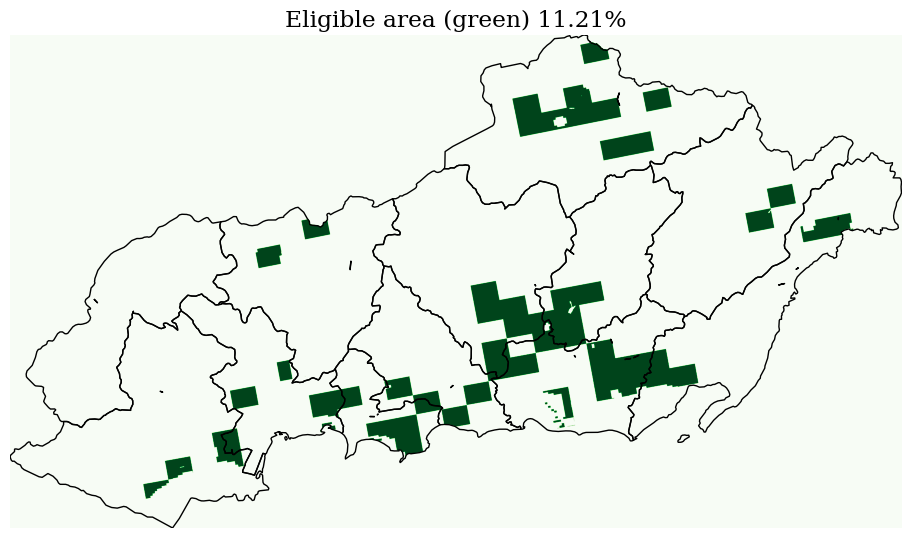

In [4]:
step2_results=RES_module.get_cell_capacity()

  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
  └─> RES.CellCapacityProcessor| Using provided region boundary for plotting.
  └─> RES.CellCapacityProcessor| Using provided Availability matrix for plotting.
  └─> RES.CellCapacityProcessor|Land availability (grid cells) map saved at vis/AL/lands/land_availability_ERA5grid_AL.png


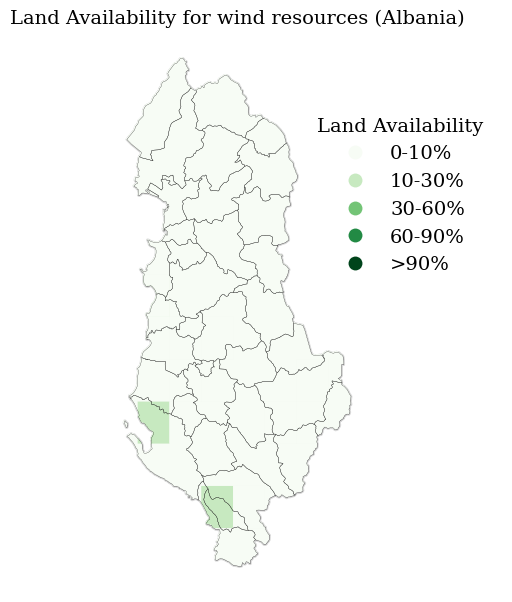

In [14]:
figure=RES_module.cell_processor.plot_ERAF5_grid_land_availability(region_boundary=RES_module.gadmBoundary.get_region_boundary(),
                                                            Availability_matrix=RES_module.cell_processor.Availability_matrix,
                                                            figsize=(9, 8),
                                                            legend_box_x_y=(1.6, 0.9))


In [7]:
step2_results[0].head(4)

,y,x,potential_capacity_wind,capex_wind,fom_wind,vom_wind,grid_connection_cost_per_km_wind,tx_line_rebuild_cost_wind,Operational_life_wind,Country,Municipality,City,geometry
cell,,,,,,,,,,,,,
Delvinës_20.0_39.75,39.75,20.00,0.0,1.564557,0.040427,0.0,2.6,0.56,20,Albania,Vlorë,Delvinës,"POLYGON ((20.125 39.875, 20.125 39.87366, 20.1..."
Sarandës_20.0_39.75,39.75,20.00,0.0,1.564557,0.040427,0.0,2.6,0.56,20,Albania,Vlorë,Sarandës,"POLYGON ((20.125 39.65571, 20.1193 39.6583, 20..."
Gjirokastrës_20.25_39.75,39.75,20.25,0.0,1.564557,0.040427,0.0,2.6,0.56,20,Albania,Gjirokastër,Gjirokastrës,"POLYGON ((20.375 39.875, 20.375 39.77659, 20.3..."
Delvinës_20.25_39.75,39.75,20.25,0.0,1.564557,0.040427,0.0,2.6,0.56,20,Albania,Vlorë,Delvinës,"MULTIPOLYGON (((20.24102 39.875, 20.2405 39.87..."


### Step 3: Get CF and Windspeed from Higher Resolution Data

> - Currently configured for Wind Resources only. Wind resources (windspeed) are known to have significant variations across ERA5's ~30km resolution. We rescaled the windspeed with higher resolution windspeed from Global Wind Atlas (GWA). Then we calculate the ERA5 scaled windspeed from the mapped GWA cells. However, GWA does not provide hourly profiles. We source the profile from ERA5.

- returns NONE if result datafield ('windspeed_ERA5') is already there 

In [8]:
gwa_cells=RES_module.gwa_cells.load_gwa_cells()

  └─> RES.boundaries| Processing regional bounding box...
  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
  └─> RES.boundaries| Setting up the Minimum Bounding Region (MBR) for AL...
  └─> RES.gwa| 0 cells have been filtered due to Windspeed filter [0-50 m/s].
  └> ✔ Cleaned data loaded for 583237 GWA cells
  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
  └> RES.gwa| Global Wind Atlas (GWA) Cells loaded. Size: 583237


* Plot Windspeed for 100m resolution cells (not a mandatory step, for cross checking purposes)
  > That's a high resolution data, may take a while to plot. Make sure your machine's cache memory is enough to hold this data.

<Axes: >

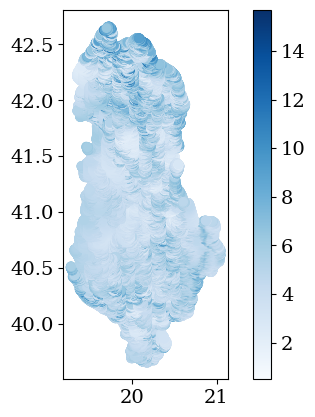

In [9]:
gwa_cells.plot('windspeed_gwa',cmap="Blues",legend=True)

### GWA Scaled Wind Speed vs ERA5 Windspeed Comparison

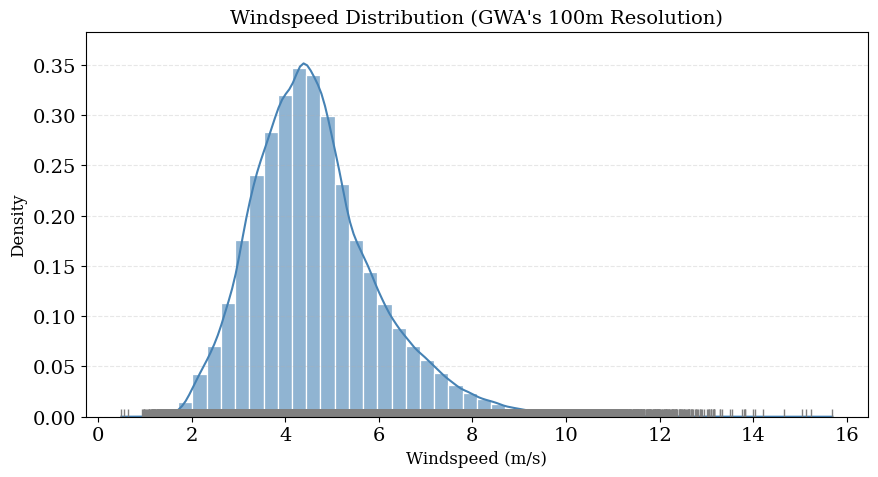

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.histplot(gwa_cells['windspeed_gwa'], bins=50, kde=True, color='steelblue', edgecolor='white', stat='density', alpha=0.6,legend=True)
sns.rugplot(gwa_cells['windspeed_gwa'], color='grey', height=0.02)

plt.title('Windspeed Distribution (GWA\'s 100m Resolution)', fontsize=14)
plt.xlabel('Windspeed (m/s)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f'vis/{country_code}/gwa_resolution_windspeed_distribution_{country_code}.jpg', dpi=300)
# plt.show()

In [20]:
step3_results_A=RES_module.extract_weather_data()

 └> RES.RESources| Extracting ERA5 windspeed from cutout...
  └─> RES.era5_cutout|  Processing ERA5's cutout...
  └─> RES.boundaries| Processing regional bounding box...
  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
  └─> RES.boundaries| Setting up the Minimum Bounding Region (MBR) for AL...
  └─> RES.era5_cutout| ✓ MBR and regional boundary created. 
ℹ️   Memory management remarks:
    * After execution, all downloaded data is stored at cutout.path. By default, it is not loaded into memory, but into dask arrays. This keeps the memory consumption extremely low.
    * The data is accessible in cutout.data, which is an xarray.Dataset. Querying the cutout gives us some basic information on which data is contained in it.
    * For more ope

In [21]:
step3_results_B=RES_module.update_gwa_scaled_params() # testing, 2025 04 21

  └> RES.RESources| Preparing high resolution windspeed data from Global Wind Atlas
  └─> RES.RESources| 'CF_IEC2', 'CF_IEC3', 'windspeed_gwa' are already present in the store information, skipping data extraction from source


In [23]:
step3_results_B.head(4)

,x_1,y_1,windspeed_gwa,CF_IEC1,CF_IEC2,CF_IEC3,x,y,potential_capacity_wind,capex_wind,fom_wind,vom_wind,grid_connection_cost_per_km_wind,tx_line_rebuild_cost_wind,Operational_life_wind,windspeed_ERA5,Country,Municipality,City,geometry
cell,,,,,,,,,,,,,,,,,,,,
Delvinës_20.0_39.75,20.077297,39.870020,3.374273,0.091636,0.104218,0.118119,20.00,39.75,0.0,1.564557,0.0,0.0404,0.0,0.0,20.0,NaN,Albania,Vlorë,Delvinës,"POLYGON ((20.11477 39.875, 20.1115 39.8736, 20..."
Delvinës_20.0_40.0,20.022125,39.979898,3.664169,0.108349,0.122858,0.138767,20.00,40.00,0.0,1.564557,0.0,0.0404,0.0,0.0,20.0,3.139977,Albania,Vlorë,Delvinës,"POLYGON ((20.125 39.87937, 20.11477 39.875, 20..."
Delvinës_20.25_39.75,20.214931,39.871667,4.919282,0.168518,0.191003,0.218639,20.25,39.75,0.0,1.564557,0.0,0.0404,0.0,0.0,20.0,NaN,Albania,Vlorë,Delvinës,"POLYGON ((20.23679 39.875, 20.2378 39.8698, 20..."
Delvinës_20.25_40.0,20.168177,39.919126,4.220576,0.132513,0.150369,0.170984,20.25,40.00,0.0,1.564557,0.0,0.0404,0.0,0.0,20.0,NaN,Albania,Vlorë,Delvinës,"POLYGON ((20.125 39.97929, 20.1321 39.976, 20...."


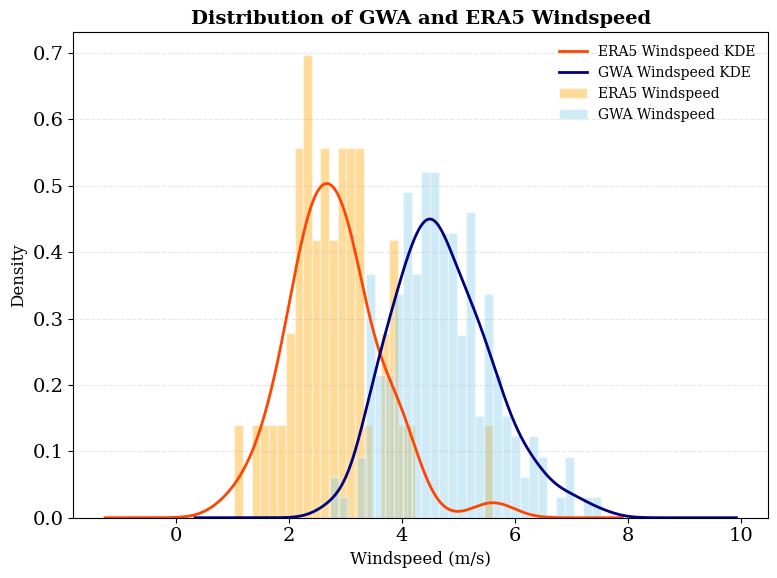

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot KDEs
step3_results_B['windspeed_ERA5'].plot.kde(color='orangered', linewidth=2, label='ERA5 Windspeed KDE')
step3_results_B['windspeed_gwa'].plot.kde(color='navy', linewidth=2, label='GWA Windspeed KDE')

# Plot histograms
step3_results_B['windspeed_ERA5'].plot.hist(bins=30, color='orange', edgecolor='white', density=True, alpha=0.4, label='ERA5 Windspeed')
step3_results_B['windspeed_gwa'].plot.hist(bins=30, color='skyblue', edgecolor='white', density=True, alpha=0.4, label='GWA Windspeed')

plt.title('Distribution of GWA and ERA5 Windspeed', fontsize=14, weight='bold')
plt.xlabel('Windspeed (m/s)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(f'vis/{country_code}/ERA5_resolution_windspeed_distribution_ERA5vsGWA_{country_code}.png', dpi=300)
plt.show()

In [26]:
RES_module.datahandler.refresh()

In [27]:
RES_module.datahandler.from_store('cells').columns

Index(['x_1', 'y_1', 'windspeed_gwa', 'CF_IEC1', 'CF_IEC2', 'CF_IEC3', 'x',
       'y', 'potential_capacity_wind', 'capex_wind', 'fom_wind', 'vom_wind',
       'grid_connection_cost_per_km_wind', 'tx_line_rebuild_cost_wind',
       'Operational_life_wind', 'windspeed_ERA5', 'Country', 'Municipality',
       'City', 'geometry'],
      dtype='object')

### Step 4: Get Timeseries

In [29]:
step4_results=RES_module.get_CF_timeseries()

  └─> RES.RESources| Preparing Timeseries for the Cells...
└> >> Loading ERA5 Cutout
  └─> RES.era5_cutout|  Processing ERA5's cutout...
  └─> RES.boundaries| Processing regional bounding box...
  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
  └─> RES.boundaries| Setting up the Minimum Bounding Region (MBR) for AL...
  └─> RES.era5_cutout| ✓ MBR and regional boundary created. 
ℹ️   Memory management remarks:
    * After execution, all downloaded data is stored at cutout.path. By default, it is not loaded into memory, but into dask arrays. This keeps the memory consumption extremely low.
    * The data is accessible in cutout.data, which is an xarray.Dataset. Querying the cutout gives us some basic information on which data is contained 

### Step 5: Find Grid Proximity

In [31]:
step5_results

NameError: name 'step5_results' is not defined

In [32]:
step5_results=RES_module.find_grid_nodes(use_pypsa_buses=False,
                                         apply_proximity_filter=True)  # use_pypsa_buses=False

  └─> RES.era5_cutout|  Processing ERA5's cutout...
  └─> RES.boundaries| Processing regional bounding box...
  └─> RES.boundaries| Region Set to >> Short Code : AL, Name: Albania).
  └─> RES.boundaries| Collecting regional boundary...
  └─> RES.boundaries| Loading GADM boundaries (Sub-provincial | level =2) for Albania from local file data/processed_data/regions/gadm41_Western Balkan Regions_L2_AL.geojson.
  └─> RES.boundaries| Setting up the Minimum Bounding Region (MBR) for AL...
  └─> RES.era5_cutout| ✓ MBR and regional boundary created. 
ℹ️   Memory management remarks:
    * After execution, all downloaded data is stored at cutout.path. By default, it is not loaded into memory, but into dask arrays. This keeps the memory consumption extremely low.
    * The data is accessible in cutout.data, which is an xarray.Dataset. Querying the cutout gives us some basic information on which data is contained in it.
    * For more operations related to cutout, check the tool docs @ https://atl

AttributeError: Attribute 'block0_items_variety' does not exist in node: '/cells'

### Step 6: Scoring Metric to Rank the Sites

In [33]:
step6_results=RES_module.score_cells()

AttributeError: Attribute 'block0_items_variety' does not exist in node: '/cells'

### Step 7: Clusterized Representation of the Sites

In [ ]:
step7_results_Clusters=RES_module.get_clusters()
step7_results_ClusterTS=RES_module.get_cluster_timeseries()

In [ ]:
utils_dict=RES_module.units.create_units_dictionary()

# [Exploratory]

### Explore the outputs from Store

In [ ]:
from RES.hdf5_handler import DataHandler
res_store=DataHandler(f'data/store/resources_{province_code}.h5')

In [ ]:
cells=res_store.from_store('cells')
boundary=res_store.from_store('boundary')
solar_clusters=res_store.from_store('clusters/solar')
wind_clusters=res_store.from_store('clusters/wind')
solar_clusters_ts=res_store.from_store('timeseries/clusters/solar')
wind_clusters_ts=res_store.from_store('timeseries/clusters/wind')

- Interactive Map

In [ ]:
# wind_clusters[wind_clusters['lcoe']<=100].explore('potential_capacity')

# Playground for Top Site Selection

In [ ]:
resource_clusters_solar,cluster_timeseries_solar=RES_module.select_top_sites(solar_clusters,
                                                                solar_clusters_ts,
                                                                    resource_max_capacity=10)

resource_clusters_wind,cluster_timeseries_wind=RES_module.select_top_sites(wind_clusters,
                                                                wind_clusters_ts,
                                                                    resource_max_capacity=50)

In [ ]:
RES_module.export_results('wind',
                    resource_clusters_wind,
                    cluster_timeseries_wind,)

In [ ]:
RES_module.export_results('solar',
                    resource_clusters_solar,
                    cluster_timeseries_solar,)

In [ ]:
# resource_clusters_solar.plot('potential_capacity',legend=True)
# resource_clusters_wind.plot('potential_capacity',legend=True)

# Visualize Results

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

legend_x_ax_offset=1
# Ensure 'Region' is in the columns for both boundary and cells
if 'Region' not in boundary.columns:
    boundary = boundary.reset_index(inplace=True)

# Assign a number to each region
boundary['Region_Number'] = range(1, len(boundary) + 1)

# Define custom bins and labels for solar and wind capacity
solar_bins = [0, 100, 200, 300, 500, float('inf')]  # Custom ranges
solar_labels = ['<100','100-200', '200-300', '300-500','>500']  # Labels for legend

# Define custom bins and labels for solar and wind capacity
wind_bins = [0, 300, 500, 1000, 2000,3000, float('inf')]  # Custom ranges
wind_labels = ['<300','300-500', '500-1000', '1000-2000','2000-3000', '>3000']  # Labels for legend

# Categorize potential_capacity_solar and potential_capacity_wind into bins
resource_clusters_solar['solar_category'] = pd.cut(resource_clusters_solar['potential_capacity'], bins=solar_bins, labels=solar_labels, include_lowest=True)
resource_clusters_wind['wind_category'] = pd.cut(resource_clusters_wind['potential_capacity'], bins=wind_bins, labels=wind_labels, include_lowest=True)

# Create figure and axes for side-by-side plotting
fig, (ax1, ax2) = plt.subplots(figsize=(18, 8), ncols=2)
fig.suptitle("Potential Sites for Targeted Capacity Investments", fontsize=16,weight='bold')
# Set axis off for both subplots
ax1.set_axis_off()
ax2.set_axis_off()

# Shadow effect offset
shadow_offset = 0.01

# Plot solar map on ax1
# Add shadow effect for solar map
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax1, color='None', edgecolor='grey', linewidth=1, alpha=0.7)  # Shadow layer
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot solar cells
resource_clusters_solar.plot(column='solar_category', ax=ax1, cmap='Wistia', legend=True, 
           legend_kwds={'title': "Solar Capacity (MW)", 'loc': 'upper right','bbox_to_anchor':(legend_x_ax_offset,1), 'frameon': False})

# Plot actual boundary for solar map
boundary.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.2, alpha=0.7)
"""
# Annotate region numbers for solar map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax1.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=7, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Plot wind map on ax2
# Add shadow effect for wind map
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax2, color='None', edgecolor='grey', linewidth=1, alpha=0.7)  # Shadow layer
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot wind cells
resource_clusters_wind.plot(column='wind_category', ax=ax2, cmap='summer', legend=True, 
           legend_kwds={'title': "Wind Capacity (MW)", 'bbox_to_anchor':(legend_x_ax_offset,1), 'frameon': False})

# Plot actual boundary for wind map
boundary.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.2, alpha=0.7)
"""
# Annotate region numbers for wind map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax2.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=8, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Adjust layout for cleaner appearance
fig.patch.set_alpha(0)  # Make figure background transparent
plt.tight_layout()

# Show the side-by-side plot

# plt.savefig('solar_wind_capacity_map.png',dpi=300)
plt.show()